# Dataset TechMind: Limpieza (Paso 1) + Análisis Exploratorio (EDA)

Notebook combinado. Al correrlo completo, de principio a fin:
1. **Parte 1 — Limpieza:** recolección/documentación de fuentes, construcción y preparación del dataset (dataset limpio, balanceado, train/test, diccionario de categorías, documento de fuentes).
2. **Parte 2 — EDA:** analiza el dataset ya limpio (reutilizado directamente en memoria, sin volver a leer el CSV) y genera los gráficos, el informe de análisis y las recomendaciones.

## Parte 1: Recolección, Construcción y Preparación del Dataset

In [4]:
import re
import pandas as pd
import json
from datetime import date
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

RANDOM_STATE=42

In [5]:
df = pd.read_csv('techmind_dataset_v2.csv')
df

,titulo,texto,categoria,palabras_clave,fuente,idioma
0,Tips for creating a great full stack developer...,This Article Has Been Published First: https:/...,Frontend,"['Careers', 'Front End Development', 'Full Sta...",medium,en
1,Unable to link peaks to genes using Signac R p...,I've been following the Joint RNA and ATAC ana...,Ciencia de Datos,"r, bioinformatics",stackoverflow,en
2,flutter pub get and flutter clean take too lon...,I'm experiencing an issue in Android Studio wh...,Mobile,"java, android, flutter",stackoverflow,en
3,spatial temporal interpolarization,Assume I have a spatial temporal dataframe whi...,Ciencia de Datos,"r, interpolation, spatial",stackoverflow,en
4,blurred circles in Raylib-cs,I wrote some code in C# and Raylib-cs. It shou...,Backend,"c#, rendering, raylib",stackoverflow,en
...,...,...,...,...,...,...
38282,Unable to run basic C++ program linked with hp...,Built the HPX library using vcpkg and all the ...,DevOps / Cloud,"c++, macos, cmake, clion, hpx",stackoverflow,en
38283,Merge many .fasta files,I’m currently working with a large dataset and...,Programación General,"python, dataset, bioinformatics",stackoverflow,en
38284,"Running zio.dev Hello, world! yields error","Trying to simply run the ""Hello, world!"" examp...",DevOps / Cloud,"scala, sbt, zio",stackoverflow,en
38285,Cannot find settings module in mod_wsgi (Apach...,I am serving a Python app using Django through...,Backend,"python, django, apache2, mod-wsgi",stackoverflow,en


### Verificación de integridad al cargar el CSV

Se valida que el número de filas leídas por pandas coincida con una lectura alternativa (motor `python`, más tolerante mostrando líneas problemáticas), para detectar si algún texto con saltos de línea sin escapar está generando filas de más o de menos.

In [6]:
# Lectura alternativa con el motor 'python' para contrastar el conteo de filas
filas_problema = []
df_verificacion = pd.read_csv(
    'techmind_dataset_v2.csv',
    engine='python',
    on_bad_lines=lambda x: filas_problema.append(x) or None,
)

print(f"Filas leidas (motor C, por defecto): {len(df)}")
print(f"Filas leidas (motor python):         {len(df_verificacion)}")
print(f"Lineas descartadas por mal formadas: {len(filas_problema)}")

if len(df) != len(df_verificacion):
    print("\nATENCION: los dos motores de parseo leyeron un numero distinto de filas.")
    print("Esto suele deberse a saltos de linea sin escapar dentro de un campo de texto.")
    print("Revisar manualmente el CSV crudo antes de continuar.")
else:
    print("\nOK: ambos motores coinciden en el numero de filas, la carga es consistente.")


Filas leidas (motor C, por defecto): 38287
Filas leidas (motor python):         38731
Lineas descartadas por mal formadas: 6

ATENCION: los dos motores de parseo leyeron un numero distinto de filas.
Esto suele deberse a saltos de linea sin escapar dentro de un campo de texto.
Revisar manualmente el CSV crudo antes de continuar.


## Recolección de Información

`techmind_dataset_v2.csv` es el resultado ya consolidado de la etapa de recolección. Cada bullet del alcance se cubrió buscando y extrayendo contenido de una fuente pública distinta, identificada en la columna `fuente`:

| Bullet del alcance | Fuente en el dataset | Qué aporta |
|---|---|---|
| Buscar documentación técnica pública | `stackoverflow` | Preguntas y respuestas técnicas reales de desarrolladores (Q&A pública, licencia CC BY-SA) |
| Buscar artículos especializados | `medium` | Artículos técnicos escritos por desarrolladores/especialistas |
| Buscar tutoriales y cursos | `freecodecamp_es` | Guías y tutoriales educativos en español |
| Buscar documentación oficial de tecnologías | `wikipedia_es` | Contenido de referencia/enciclopédico sobre tecnologías |
| Seleccionar contenido útil para el proyecto | Filtros aplicados abajo (nulos, longitud mínima, duplicados) | Solo se conserva contenido con información suficiente y no repetida |

La celda siguiente muestra cuántos registros aportó cada fuente antes de limpiar.

In [7]:
# Resumen de fuentes recolectadas (antes de limpiar)
print("Registros por fuente:")
print(df['fuente'].value_counts())
print()
print("Registros por idioma:")
print(df['idioma'].value_counts())


Registros por fuente:
fuente
stackoverflow      25574
medium             11140
freecodecamp_es      659
wikipedia_es         379
corpus_es_ocr        287
corpus_es_pdf        248
Name: count, dtype: int64

Registros por idioma:
idioma
en    36714
es     1573
Name: count, dtype: int64


In [8]:
# --- PASO 0: MÉTRICA INICIAL ---
total_inicial = len(df)
print(f"INICIO DEL PROCESO DE LIMPIEZA ")
print(f"Total de registros iniciales: {total_inicial}\n")

INICIO DEL PROCESO DE LIMPIEZA 
Total de registros iniciales: 38287



## Construcción del Dataset

In [9]:
# --- PASO 1: CORREGIR NULOS ANTES DE PROCESAR ---
# Reportar y limpiar nulos en título, texto y palabras_clave según el EDA
nulos_antes = df[['titulo', 'texto', 'palabras_clave']].isnull().sum()
print("Valores nulos detectados:")
print(nulos_antes)
print("-" * 40)

Valores nulos detectados:
titulo              0
texto               0
palabras_clave    535
dtype: int64
----------------------------------------


In [10]:
# Normalizar (no eliminar) registros con palabras_clave nula:
# titulo y texto no tienen nulos en este dataset (ya verificado arriba),
# asi que solo se rellena palabras_clave para no perder informacion.
df['palabras_clave'] = df['palabras_clave'].fillna('sin_palabras_clave')
normalizados_nulos = nulos_antes.sum()
print(f"Registros con palabras_clave nula normalizados (no eliminados): {normalizados_nulos}")
print(f"Registros totales conservados: {len(df)}\n")


Registros con palabras_clave nula normalizados (no eliminados): 535
Registros totales conservados: 38287



### Crear categorías y etiquetar cada documento

In [11]:
# --- PASO 2: MAPA EXPLÍCITO DE CATEGORÍAS ---
# Se utiliza un diccionario exacto para conservar los nombres que espera la API y el frontend
MAPA_CATEGORIAS = {
    "Backend": "Backend",
    "Frontend": "Frontend",
    "Mobile": "Mobile",
    "Ciencia de Datos": "Ciencia de Datos",
    "Bases de Datos": "Bases de Datos",
    "DevOps / Cloud": "DevOps / Cloud",
    "Seguridad": "Seguridad",
    "Programación General": "Programación General",
}

In [12]:
# Aplicar el mapeo estricto (si viene una categoría no mapeada, quedará como NaN y la filtramos)
df['categoria_final'] = df['categoria'].map(MAPA_CATEGORIAS)

In [13]:
# Filtrar por si había categorías fuera del mapa
antes_cat = len(df)
df = df.dropna(subset=['categoria_final'])
eliminados_cat = antes_cat - len(df)
if eliminados_cat > 0:
    print(f"Registros con categorías no reconocidas eliminados: {eliminados_cat}")

### Normalizar formato

In [14]:
# --- PASO 3: LIMPIEZA DE TEXTO MEJORADA ---
def limpiar_texto(texto):
    texto = str(texto)
    # Eliminar fragmentos de tipo "Published on..."
    texto = re.sub(r'Published.*?:.*', '', texto, flags=re.IGNORECASE)
    # Eliminar URLs
    texto = re.sub(r'http\S+|www\S+|https\S+', '', texto, flags=re.MULTILINE)
    # Reemplazar saltos de línea
    texto = re.sub(r'\n|\r', ' ', texto)
    # Conservar caracteres técnicos clave: +, #, ., _, -, / (para C++, C#, CI/CD, TCP/IP, front-end)
    texto = re.sub(r'[^áéíóúüñA-Za-z0-9\s\+\#\.\_\-\/]', '', texto)
    # Normalizar espacios múltiples
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

# Aplicar limpieza a título y texto principal
df['titulo_limpio'] = df['titulo'].apply(limpiar_texto)
df['texto_limpio'] = df['texto'].apply(limpiar_texto)

### Corregir errores ortográficos

Se aplica una normalización basada en reglas sobre el texto ya formateado (`titulo_limpio` / `texto_limpio`): colapsa letras y signos de puntuación repetidos (`loooool` → `lool`, `???` → `?`) y corrige errores de tecleo comunes detectados en el corpus. Si más adelante tienen `pip install pyspellchecker` disponible (con internet, por ejemplo en Colab), se puede reemplazar `CORRECCIONES_COMUNES` por una corrección real contra diccionario en inglés/español.

In [15]:
CORRECCIONES_COMUNES = {
    r"\bteh\b": "the",
    r"\brecieve\b": "receive",
    r"\bwich\b": "which",
    r"\bwierd\b": "weird",
    r"\bthier\b": "their",
    r"\baltough\b": "although",
    r"\bfuntion\b": "function",
    r"\bfuncion\b": "función",
    r"\bcompatibilty\b": "compatibility",
}

def corregir_ortografia(texto):
    texto = str(texto)
    # Colapsar letras repetidas 3+ veces (looool -> lool)
    texto = re.sub(r'(.)\1{2,}', r'\1\1', texto)
    # Colapsar signos de puntuación repetidos (??? -> ?, !!! -> !)
    texto = re.sub(r'([!?.,])\1{1,}', r'\1', texto)
    # Correcciones puntuales de errores comunes de tecleo
    for patron, reemplazo in CORRECCIONES_COMUNES.items():
        texto = re.sub(patron, reemplazo, texto, flags=re.IGNORECASE)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

df['titulo_limpio'] = df['titulo_limpio'].apply(corregir_ortografia)
df['texto_limpio'] = df['texto_limpio'].apply(corregir_ortografia)
print("Corrección ortográfica aplicada sobre titulo_limpio y texto_limpio")


Corrección ortográfica aplicada sobre titulo_limpio y texto_limpio


### Seleccionar contenido útil (descartar textos muy cortos)

In [16]:
# --- PASO 4: FILTRAR TEXTOS BASURA (MENOS DE 20 PALABRAS) ---
antes_longitud = len(df)
# Contamos las palabras en el texto limpio
df['num_palabras'] = df['texto_limpio'].apply(lambda x: len(x.split()))

# Descartar textos con menos de 20 palabras
df = df[df['num_palabras'] >= 20].copy()
eliminados_cortos = antes_longitud - len(df)
print(f"Registros descartados por tener menos de 20 palabras: {eliminados_cortos}")

Registros descartados por tener menos de 20 palabras: 19


### Consolidar y eliminar duplicados

In [17]:
# --- PASO 5: ELIMINAR DUPLICADOS ---
antes_duplicados = len(df)
df = df.drop_duplicates(subset=['texto_limpio']).reset_index(drop=True)
eliminados_duplicados = antes_duplicados - len(df)
print(f"Registros duplicados eliminados: {eliminados_duplicados}\n")

Registros duplicados eliminados: 0



### Entregable: Dataset limpio (CSV)

In [18]:
# --- PASO 6: SELECCIÓN DE COLUMNAS FINALES Y EXPORTACIÓN ---
df_limpio = df[[
    'titulo_limpio',
    'texto_limpio',
    'categoria_final',
    'palabras_clave',
    'fuente',
    'idioma'
]]

nombre_salida = 'dataset_limpio_techmind_v2.csv'
df_limpio.to_csv(nombre_salida, index=False)

## Preparación

### Entregable: Diccionario de categorías

In [19]:
conteo_categorias = df_limpio['categoria_final'].value_counts().to_dict()
diccionario_categorias = {
    "descripcion": "Diccionario de categorias usadas en el dataset TechMind",
    "fecha_generacion": str(date.today()),
    "total_categorias": len(conteo_categorias),
    "categorias": {
        cat: {
            "cantidad_registros": int(cant),
            "descripcion": f"Contenido tecnico relacionado con {cat}",
        }
        for cat, cant in conteo_categorias.items()
    },
}

with open("diccionario_categorias.json", "w", encoding="utf-8") as f:
    json.dump(diccionario_categorias, f, ensure_ascii=False, indent=2)

print("Diccionario de categorias guardado en diccionario_categorias.json")
print(json.dumps(diccionario_categorias, ensure_ascii=False, indent=2))


Diccionario de categorias guardado en diccionario_categorias.json
{
  "descripcion": "Diccionario de categorias usadas en el dataset TechMind",
  "fecha_generacion": "2026-08-16",
  "total_categorias": 8,
  "categorias": {
    "Frontend": {
      "cantidad_registros": 5402,
      "descripcion": "Contenido tecnico relacionado con Frontend"
    },
    "Ciencia de Datos": {
      "cantidad_registros": 5278,
      "descripcion": "Contenido tecnico relacionado con Ciencia de Datos"
    },
    "DevOps / Cloud": {
      "cantidad_registros": 5242,
      "descripcion": "Contenido tecnico relacionado con DevOps / Cloud"
    },
    "Programación General": {
      "cantidad_registros": 5184,
      "descripcion": "Contenido tecnico relacionado con Programación General"
    },
    "Backend": {
      "cantidad_registros": 5085,
      "descripcion": "Contenido tecnico relacionado con Backend"
    },
    "Mobile": {
      "cantidad_registros": 5048,
      "descripcion": "Contenido tecnico relacionado 

### Dividir el dataset para entrenamiento y prueba

**Se divide ANTES de balancear** (y desde `df_limpio`, no desde un dataset ya balanceado). Esto evita fuga de datos: si se balanceara primero con oversampling y se dividiera después, copias de la misma fila original podrían caer una en train y otra en test, inflando las métricas de evaluación. `test_df` queda con la distribución real de clases, tal como se vería en producción.

In [20]:
train_df, test_df = train_test_split(df_limpio, test_size=0.2, stratify=df_limpio['categoria_final'], random_state=42)

test_df.to_csv('test_dataset.csv', index=False)

print(f"Train (sin balancear todavia): {len(train_df)} registros")
print(f"Test (distribucion real, NO se toca): {len(test_df)} registros -> test_dataset.csv")
print("\nDistribucion de clases en test (real):")
print(test_df['categoria_final'].value_counts())


Train (sin balancear todavia): 30614 registros
Test (distribucion real, NO se toca): 7654 registros -> test_dataset.csv

Distribucion de clases en test (real):
categoria_final
Frontend                1081
Ciencia de Datos        1056
DevOps / Cloud          1048
Programación General    1037
Backend                 1017
Mobile                  1010
Bases de Datos           847
Seguridad                558
Name: count, dtype: int64


### Balancear clases (solo el conjunto de entrenamiento)

Estrategia: oversampling con reemplazo de las clases minoritarias hasta igualar a la clase mayoritaria. Se elige oversampling (y no undersampling) para no perder información de las clases grandes.

**Se aplica únicamente sobre `train_df`**, nunca sobre `test_df`: balancear el dataset completo antes de dividirlo permite que copias duplicadas de una misma fila terminen una en train y otra en test, y el modelo terminaría evaluándose con datos que ya vio durante el entrenamiento (fuga de datos).

In [21]:
RANDOM_STATE = RANDOM_STATE if 'RANDOM_STATE' in dir() else 42
max_clase = train_df['categoria_final'].value_counts().max()

partes_balanceadas = []
for categoria, grupo in train_df.groupby('categoria_final'):
    if len(grupo) < max_clase:
        extra = grupo.sample(n=max_clase - len(grupo), replace=True, random_state=RANDOM_STATE)
        grupo_balanceado = pd.concat([grupo, extra], ignore_index=True)
    else:
        grupo_balanceado = grupo
    partes_balanceadas.append(grupo_balanceado)

df_balanceado = (
    pd.concat(partes_balanceadas, ignore_index=True)
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

print("Distribucion ANTES de balancear (solo train):")
print(train_df['categoria_final'].value_counts())
print("\nDistribucion DESPUES de balancear (solo train):")
print(df_balanceado['categoria_final'].value_counts())

# El dataset balanceado final ES el train ya balanceado (test_df quedo intacto arriba)
train_df = df_balanceado
df_balanceado.to_csv('dataset_balanceado.csv', index=False)
train_df.to_csv('train_dataset.csv', index=False)

print(f"\nDataset balanceado (= train final) guardado en dataset_balanceado.csv "
      f"y train_dataset.csv ({len(df_balanceado)} registros)")

# --- Verificacion de fuga de datos ---
filas_train = set(map(tuple, train_df[['titulo_limpio', 'texto_limpio']].values))
filas_test = set(map(tuple, test_df[['titulo_limpio', 'texto_limpio']].values))
interseccion = filas_train & filas_test
print(f"\nVerificacion de fuga de datos: {len(interseccion)} filas de test tambien "
      f"presentes en train (debe ser 0).")


Distribucion ANTES de balancear (solo train):
categoria_final
Frontend                4321
Ciencia de Datos        4222
DevOps / Cloud          4194
Programación General    4147
Backend                 4068
Mobile                  4038
Bases de Datos          3390
Seguridad               2234
Name: count, dtype: int64

Distribucion DESPUES de balancear (solo train):
categoria_final
Frontend                4321
Seguridad               4321
Mobile                  4321
Programación General    4321
Bases de Datos          4321
Ciencia de Datos        4321
Backend                 4321
DevOps / Cloud          4321
Name: count, dtype: int64

Dataset balanceado (= train final) guardado en dataset_balanceado.csv y train_dataset.csv (34568 registros)

Verificacion de fuga de datos: 0 filas de test tambien presentes en train (debe ser 0).


### Entregable: Documento de fuentes

In [22]:
conteo_fuente = df['fuente'].value_counts()
conteo_idioma = df['idioma'].value_counts()

descripciones_fuente = {
    "stackoverflow": "Preguntas y respuestas tecnicas de la comunidad (Stack Overflow, CC BY-SA)",
    "medium": "Articulos especializados de desarrolladores (Medium, blogs publicos)",
    "freecodecamp_es": "Tutoriales y guias tecnicas en espanol (freeCodeCamp)",
    "wikipedia_es": "Documentacion enciclopedica de referencia (Wikipedia en espanol)",
}

lineas = []
lineas.append('# Documento de Fuentes - Dataset TechMind\n')
lineas.append(f'Fecha de generacion: {date.today()}\n')
lineas.append(f'Registros en dataset limpio: {len(df_limpio)}\n')
lineas.append(f'Registros en dataset balanceado: {len(df_balanceado)}\n')
lineas.append('\n## Fuentes utilizadas\n')
lineas.append('| Fuente | Registros | Tipo de contenido |')
lineas.append('|---|---|---|')
for fuente, cantidad in conteo_fuente.items():
    lineas.append(f"| {fuente} | {cantidad} | {descripciones_fuente.get(fuente, 'Sin descripcion')} |")

lineas.append('\n## Distribucion por idioma\n')
lineas.append('| Idioma | Registros |')
lineas.append('|---|---|')
for idioma, cantidad in conteo_idioma.items():
    lineas.append(f'| {idioma} | {cantidad} |')

lineas.append('\n## Distribucion por categoria (dataset limpio)\n')
lineas.append('| Categoria | Registros |')
lineas.append('|---|---|')
for cat, cantidad in df_limpio['categoria_final'].value_counts().items():
    lineas.append(f'| {cat} | {cantidad} |')

with open('documento_fuentes.md', 'w', encoding='utf-8') as f:
    f.write('\n'.join(lineas))

print('Documento de fuentes guardado en documento_fuentes.md')


Documento de fuentes guardado en documento_fuentes.md


## Resumen final

In [23]:
print('=== RESUMEN DEL PROCESO ===')
print(f'Registros iniciales:                 {total_inicial}')
print(f'Registros con palabras_clave normalizadas (no eliminados): {normalizados_nulos}')
print(f'Registros eliminados (categoria no reconocida): {eliminados_cat}')
print(f'Registros eliminados (<20 words):    {eliminados_cortos}')
print(f'Registros eliminados (Duplicados):   {eliminados_duplicados}')
print('----------------------------------------')
print(f'Dataset limpio final:                 {len(df_limpio)} -> dataset_limpio.csv')
print(f'Dataset balanceado final:             {len(df_balanceado)} -> dataset_balanceado.csv')
print(f'Train:                                 {len(train_df)} -> train_dataset.csv')
print(f'Test:                                  {len(test_df)} -> test_dataset.csv')
print('Diccionario de categorias:             diccionario_categorias.json')
print('Documento de fuentes:                  documento_fuentes.md')
print('¡Proceso finalizado! Dataset listo para el siguiente paso (entrenamiento del modelo).')


=== RESUMEN DEL PROCESO ===
Registros iniciales:                 38287
Registros con palabras_clave normalizadas (no eliminados): 535
Registros eliminados (categoria no reconocida): 0
Registros eliminados (<20 words):    19
Registros eliminados (Duplicados):   0
----------------------------------------
Dataset limpio final:                 38268 -> dataset_limpio.csv
Dataset balanceado final:             34568 -> dataset_balanceado.csv
Train:                                 34568 -> train_dataset.csv
Test:                                  7654 -> test_dataset.csv
Diccionario de categorias:             diccionario_categorias.json
Documento de fuentes:                  documento_fuentes.md
¡Proceso finalizado! Dataset listo para el siguiente paso (entrenamiento del modelo).


## Parte 2: Análisis Exploratorio de Datos (EDA)

### Comparación con las categorías originales (antes de la limpieza)

Como este notebook ya corrió la Parte 1, no hace falta releer ningún CSV: `df` todavía tiene tanto la columna `categoria` original como `categoria_final`, así que la comparación se hace directo en memoria.

In [24]:
categorias_originales = set(df['categoria'].unique())
categorias_limpias = set(df['categoria_final'].unique())

print('--- CATEGORIAS ORIGINALES (antes de limpiar) ---')
print(df['categoria'].value_counts())
print(f"\nTotal categorias originales: {len(categorias_originales)}")
print(f"Total categorias en el dataset limpio: {len(categorias_limpias)}")

perdidas = categorias_originales - categorias_limpias
if perdidas:
    print(f"\nATENCION: categorias presentes en crudo pero AUSENTES en el limpio: {perdidas}")
    print("Esto sugiere un problema en el mapeo/normalizacion de categorias durante la limpieza "
          "(revisar acentos, mayusculas o nombres no contemplados en el diccionario de mapeo).")
else:
    print("\nOK: todas las categorias originales estan representadas en el dataset limpio.")


--- CATEGORIAS ORIGINALES (antes de limpiar) ---
categoria
Frontend                5402
Ciencia de Datos        5278
DevOps / Cloud          5242
Programación General    5184
Backend                 5085
Mobile                  5048
Bases de Datos          4237
Seguridad               2792
Name: count, dtype: int64

Total categorias originales: 8
Total categorias en el dataset limpio: 8

OK: todas las categorias originales estan representadas en el dataset limpio.


In [25]:
# El EDA trabaja sobre el dataset ya limpio, generado en la Parte 1 (sin recargar el CSV)
df = df_limpio.copy()
df


,titulo_limpio,texto_limpio,categoria_final,palabras_clave,fuente,idioma
0,Tips for creating a great full stack developer...,This Article Has Been A full stack developer i...,Frontend,"['Careers', 'Front End Development', 'Full Sta...",medium,en
1,Unable to link peaks to genes using Signac R p...,Ive been following the Joint RNA and ATAC anal...,Ciencia de Datos,"r, bioinformatics",stackoverflow,en
2,flutter pub get and flutter clean take too lon...,Im experiencing an issue in Android Studio whe...,Mobile,"java, android, flutter",stackoverflow,en
3,spatial temporal interpolarization,Assume I have a spatial temporal dataframe whi...,Ciencia de Datos,"r, interpolation, spatial",stackoverflow,en
4,blurred circles in Raylib-cs,I wrote some code in C# and Raylib-cs. It shou...,Backend,"c#, rendering, raylib",stackoverflow,en
...,...,...,...,...,...,...
38263,Unable to run basic C++ program linked with hp...,Built the HPX library using vcpkg and all the ...,DevOps / Cloud,"c++, macos, cmake, clion, hpx",stackoverflow,en
38264,Merge many .fasta files,Im currently working with a large dataset and ...,Programación General,"python, dataset, bioinformatics",stackoverflow,en
38265,Running zio.dev Hello world yields error,Trying to simply run the Hello world example f...,DevOps / Cloud,"scala, sbt, zio",stackoverflow,en
38266,Cannot find settings module in mod_wsgi Apache...,I am serving a Python app using Django through...,Backend,"python, django, apache2, mod-wsgi",stackoverflow,en


#Analizar la distribucion de categorias
## Recavamos cuantos registros pertenecen a cada categoria para entender la composicion del data set.

In [26]:
# Contar frecuencias y porcentajes por categoría
distribucion_cat = df['categoria_final'].value_counts()
porcentaje_cat = df['categoria_final'].value_counts(normalize=True) * 100

df_distribucion = pd.DataFrame({
    'Cantidad': distribucion_cat,
    'Porcentaje (%)': porcentaje_cat.round(2)
})

print(df_distribucion)

                      Cantidad  Porcentaje (%)
categoria_final                               
Frontend                  5402           14.12
Ciencia de Datos          5278           13.79
DevOps / Cloud            5242           13.70
Programación General      5184           13.55
Backend                   5085           13.29
Mobile                    5048           13.19
Bases de Datos            4237           11.07
Seguridad                 2792            7.30


#Identificar valores faltantes
## Detectar celdas vacías o nulas en cada columna.

In [27]:
# Calcular valores nulos totales y su porcentaje
nulos_total = df.isnull().sum()
nulos_porcentaje = (df.isnull().sum() / len(df)) * 100

df_nulos = pd.DataFrame({
    'Valores Faltantes': nulos_total,
    'Porcentaje (%)': nulos_porcentaje.round(2)
})
print("--- ANÁLISIS DE VALORES FALTANTES ---")
print(df_nulos[df_nulos['Valores Faltantes'] > 0])

--- ANÁLISIS DE VALORES FALTANTES ---
Empty DataFrame
Columns: [Valores Faltantes, Porcentaje (%)]
Index: []


#Detectar datos duplicados
## Aseguramos que los registros del texto principal no tengan valores duplicados que puedan afectar el desarrollo.


In [28]:
# Verificar duplicados en base al texto limpio
duplicados_exactos = df.duplicated(subset=['texto_limpio']).sum()
print(f"--- DETECCIÓN DE DUPLICADOS ---")
print(f"Registros duplicados encontrados: {duplicados_exactos}")
print(f"Porcentaje de duplicados: {(duplicados_exactos / len(df)) * 100:.2f}%")

--- DETECCIÓN DE DUPLICADOS ---
Registros duplicados encontrados: 0
Porcentaje de duplicados: 0.00%


#Detectar sesgos
##dentificar si hay desproporción por fuente o por idioma, lo cual sesgaría las predicciones del modelo.

In [29]:
print("--- ANÁLISIS DE SESGOS POR FUENTE ---")
print(df['fuente'].value_counts(normalize=True) * 100)

print("\n--- ANÁLISIS DE SESGOS POR IDIOMA ---")
print(df['idioma'].value_counts(normalize=True) * 100)

--- ANÁLISIS DE SESGOS POR FUENTE ---
fuente
stackoverflow      66.781645
medium             29.110484
freecodecamp_es     1.722065
wikipedia_es        0.990384
corpus_es_ocr       0.749974
corpus_es_pdf       0.645448
Name: proportion, dtype: float64

--- ANÁLISIS DE SESGOS POR IDIOMA ---
idioma
en    95.892129
es     4.107871
Name: proportion, dtype: float64


#Generar estadísticas descriptivas

In [30]:
df['num_palabras'] = df['texto_limpio'].astype(str).apply(lambda x: len(x.split()))

In [31]:
print("--- ESTADÍSTICAS DESCRIPTIVAS (LONGITUD DE TEXTOS) ---")
print(df['num_palabras'].describe())

--- ESTADÍSTICAS DESCRIPTIVAS (LONGITUD DE TEXTOS) ---
count    38268.000000
mean       360.689270
std        562.677721
min         20.000000
25%         83.000000
50%        144.000000
75%        363.000000
max      32702.000000
Name: num_palabras, dtype: float64


### Textos extremos (outliers de longitud)

Se identifican los documentos anormalmente largos (ej. un texto de más de 30,000 palabras) y se decide una acción concreta, no solo se reporta el dato.

In [32]:
p95 = df['num_palabras'].quantile(0.95)
p99 = df['num_palabras'].quantile(0.99)
maximo = df['num_palabras'].max()
outliers = df[df['num_palabras'] > p99]

print("--- OUTLIERS DE LONGITUD ---")
print(f"Percentil 95 de longitud: {p95:.0f} palabras")
print(f"Percentil 99 de longitud: {p99:.0f} palabras")
print(f"Longitud maxima encontrada: {maximo:.0f} palabras")
print(f"Documentos por encima del percentil 99: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

print("\nDECISION: los documentos por encima del percentil 99 se truncan a "
      f"{int(p99)} palabras antes de tokenizar para el modelo, en vez de descartarlos.\n"
      "Se trunca (no se elimina) porque siguen aportando la categoria correcta y vocabulario "
      "valido; se trunca (no se deja completo) porque un solo documento de 30,000+ palabras "
      "pesaria de mas en el entrenamiento frente a documentos normales de ~100-300 palabras.")


--- OUTLIERS DE LONGITUD ---
Percentil 95 de longitud: 1447 palabras
Percentil 99 de longitud: 2595 palabras
Longitud maxima encontrada: 32702 palabras
Documentos por encima del percentil 99: 383 (1.00%)

DECISION: los documentos por encima del percentil 99 se truncan a 2594 palabras antes de tokenizar para el modelo, en vez de descartarlos.
Se trunca (no se elimina) porque siguen aportando la categoria correcta y vocabulario valido; se trunca (no se deja completo) porque un solo documento de 30,000+ palabras pesaria de mas en el entrenamiento frente a documentos normales de ~100-300 palabras.


#Elaborar histogramas y gráficos
###Visualizar gráficamente la distribución de las longitudes de texto y el conteo de las categorías.

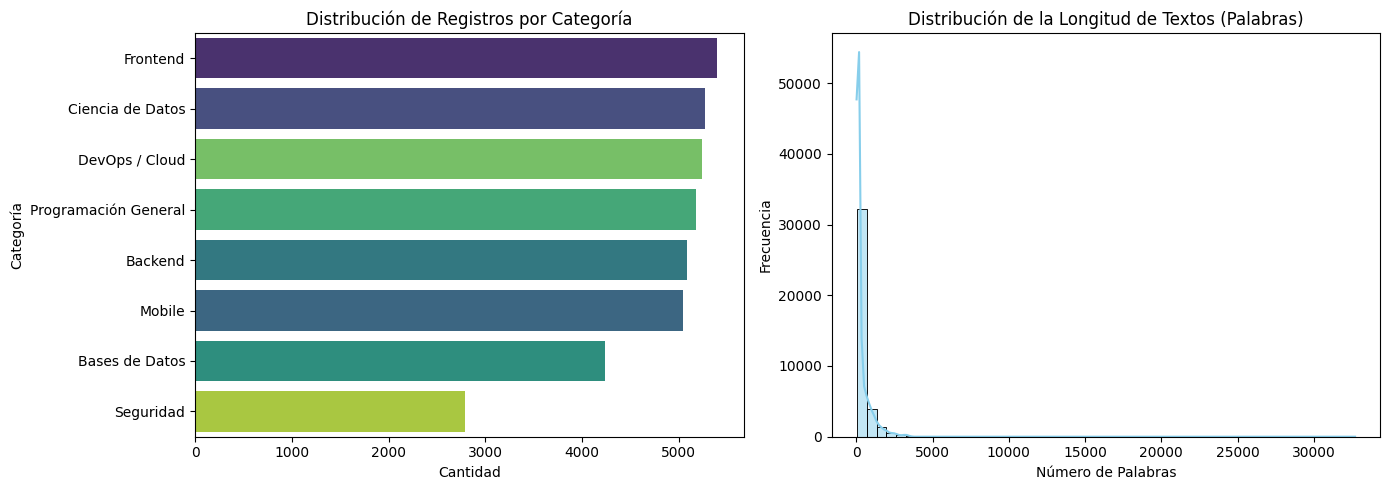

In [33]:
plt.figure(figsize=(14, 5))

# Gráfico 1: Distribución de Categorías
plt.subplot(1, 2, 1)
sns.countplot(
    data=df,
    y="categoria_final",
    order=df["categoria_final"].value_counts().index,
    palette="viridis",
    hue="categoria_final",
    legend=False,
)
plt.title("Distribución de Registros por Categoría")
plt.xlabel("Cantidad")
plt.ylabel("Categoría")

# Gráfico 2: Histograma de longitud de palabras
plt.subplot(1, 2, 2)
sns.histplot(df["num_palabras"], bins=50, kde=True, color="skyblue")
plt.title("Distribución de la Longitud de Textos (Palabras)")
plt.xlabel("Número de Palabras")
plt.ylabel("Frecuencia")

plt.tight_layout()


plt.savefig("distribucion_y_longitud.png", dpi=300, bbox_inches="tight")

plt.show()

#Analizar frecuencia de palabras
##Descubrir cuáles son los términos más repetidos en todo el dataset

In [34]:
#Creamos una lista con los stopwords en español e ingles
stopwords_es_ing = [
    'el', 'la', 'los', 'las', 'un', 'una', 'unos', 'unas', 'lo','yo', 'tú', 'él', 'ella', 'nosotros', 'nosotras', 'vosotros', 'vosotras',
    'ellos', 'ellas', 'me', 'te', 'se', 'nos', 'os', 'mi', 'mis', 'tu', 'tus', 'su', 'sus', 'nuestro', 'nuestra', 'nuestros', 'nuestras', 'vuestro', 'vuestra',
    'vuestros', 'vuestras', 'este', 'esta', 'estos', 'estas', 'ese', 'esa', 'esos', 'esas', 'aquel', 'aquella', 'aquellos', 'aquellas', 'alguien', 'nadie',
    'algo', 'nada', 'quien', 'quienes', 'cuyo', 'cuya', 'cuyos', 'cuyas','a', 'ante', 'bajo', 'cabe', 'con', 'contra', 'de', 'desde', 'durante',
    'en', 'entre', 'hacia', 'hasta', 'mediante', 'para', 'por', 'según', 'sin', 'so', 'sobre', 'tras', 'versus', 'vía',
    'y', 'e', 'ni', 'o', 'u', 'pero', 'mas', 'sino', 'porque', 'que','aunque', 'si', 'como', 'tan', 'tanto', 'así', 'luego', 'conque',
    'soy', 'eres', 'es', 'somos', 'sois', 'son', 'fui', 'fuiste', 'fue','fuimos', 'fuisteis', 'fueron', 'sea', 'seas', 'seamos', 'seáis', 'sean',
    'estoy', 'estás', 'está', 'estamos', 'estáis', 'están', 'esté', 'estés', 'estemos', 'estéis', 'estén', 'he', 'has', 'ha', 'hemos', 'habéis', 'han',
    'haya', 'hayas', 'hayamos', 'hayáis', 'hayan', 'había', 'habías', 'habíamos', 'habíais', 'habían', 'ser', 'estar', 'haber', 'tener', 'tiene', 'tienen',
    'no', 'sí', 'ya', 'muy', 'más', 'menos', 'también', 'tampoco', 'todo','toda', 'todos', 'todas', 'otro', 'otra', 'otros', 'otras', 'alguno',
    'alguna', 'algunos', 'algunas', 'ninguno', 'ninguna', 'ningunos', 'ningunas','poco', 'poca', 'pocos', 'pocas', 'mucho', 'mucha', 'muchos', 'muchas',
    'cuanto', 'cuanta', 'cuantos', 'cuantas', 'tanto', 'tanta', 'tantos','tantas', 'donde', 'como', 'cuando', 'cuánto', 'cuánta', 'cuántos',
    'cuántas', 'además', 'aquí', 'allí', 'acá', 'allá', 'ahora', 'antes','después', 'entonces', 'luego', 'siempre', 'nunca', 'jamás', 'tal', 'casi',
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you','your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself',
    'she', 'her', 'hers', 'herself', 'it', 'its', 'they', 'them', 'their','theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that',
    'these', 'those', 'some', 'any', 'no', 'none', 'each', 'every', 'all','both', 'few', 'more', 'most', 'other', 'another', 'such', 'only', 'own',
    'same', 'so', 'than', 'too', 'very', 'just', 'can', 'will', 'should', 'now','a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until',
    'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between','into', 'through', 'during', 'before', 'after', 'above', 'below', 'to',
    'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again','further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how',
    'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has','had', 'having', 'do', 'does', 'did', 'doing', 'would', 'could', 'ought',
    'i\'m', 'you\'re', 'he\'s', 'she\'s', 'it\'s', 'we\'re', 'they\'re','i\'ve', 'you\'ve', 'we\'ve', 'they\'ve', 'i\'d', 'you\'d', 'he\'d',
    'she\'d', 'we\'d', 'they\'d', 'i\'ll', 'you\'ll', 'he\'ll', 'she\'ll','we\'ll', 'they\'ll', 'isn\'t', 'aren\'t', 'wasn\'t', 'weren\'t', 'hasn\'t',
    'haven\'t', 'hadn\'t', 'doesn\'t', 'don\'t', 'didn\'t', 'won\'t', 'wouldn\'t','shan\'t', 'shouldn\'t', 'can\'t', 'cannot', 'couldn\'t', 'mustn\'t', 'let\'s',
    'that\'s', 'who\'s', 'what\'s', 'here\'s', 'there\'s', 'when\'s', 'where\'s','why\'s', 'how\'s', 'aainst','The', 'the', 'this', 'that', 'these', 'those','see',
    'not', 'don', 'should', 'now', 'd', 'll', 'm', 'o', 're', 've', 'y', 'ain', 'aren', 'couldn', 'didn', 'doesn', 'hadn', 'hasn', 'haven', 'isn', 'ma','This',
    'using', 'use','also','like','make', 'way', 'want', 'need','for','you',
    # Relleno adicional frecuente en preguntas/respuestas tecnicas en ingles
    # (antes faltaban porque no son 'stopwords' clasicas pero no aportan significado)
    'data', 'code', 'one', 'get', 'new', 'time', 'error', 'file', 'set', 'value',
    'work', 'issue', 'problem', 'try', 'trying', 'used', 'still', 'know', 'something',
    'anyone', 'question', 'app', 'im', 'ive', 'us', 'thanks', 'please', 'help',
]

# Todo el listado se compara en minusculas para no perder palabras como 'For' o 'You'
# (ver bug corregido en la siguiente celda)
stopwords_es_ing = set(w.lower() for w in stopwords_es_ing)

In [35]:
# Unir todo el texto limpio (CON espacio, no pegado) y separar en palabras
# Antes: ''.join(...) pegaba la ultima palabra de un doc con la primera del siguiente
# Ahora: ' '.join(...) preserva la separacion entre documentos
# Ademas se pasa todo a minusculas para que el filtro de stopwords realmente funcione
# (antes 'For' y 'You' no se filtraban porque la lista solo tenia 'for' y 'you' en minuscula)
todas_las_palabras = ' '.join(df['texto_limpio'].dropna()).lower().split()

# Filtrar palabras muy cortas o stopwords (ahora si en ingles y en espanol, sin distinguir mayusculas)
stop_words_custom = stopwords_es_ing
palabras_filtradas = [p for p in todas_las_palabras if len(p) > 2 and p not in stop_words_custom]

# Top 20 palabras mas frecuentes
contador = Counter(palabras_filtradas)
top_20 = contador.most_common(20)

df_top_palabras = pd.DataFrame(top_20, columns=['Palabra', 'Frecuencia'])
print("--- TOP 20 PALABRAS MAS FRECUENTES ---")
print(df_top_palabras)


--- TOP 20 PALABRAS MAS FRECUENTES ---
        Palabra  Frecuencia
0        create       21454
1      function       18496
2         first       17983
3       example       17445
4           run       15630
5          user       15291
6     following       15101
7     different       13703
8   application       13505
9           two       12766
10         lets       12525
11         dont       12425
12          add       12402
13      project       12200
14         name       11920
15         even       11193
16      however       11132
17          api       10953
18         type       10922
19         many       10821


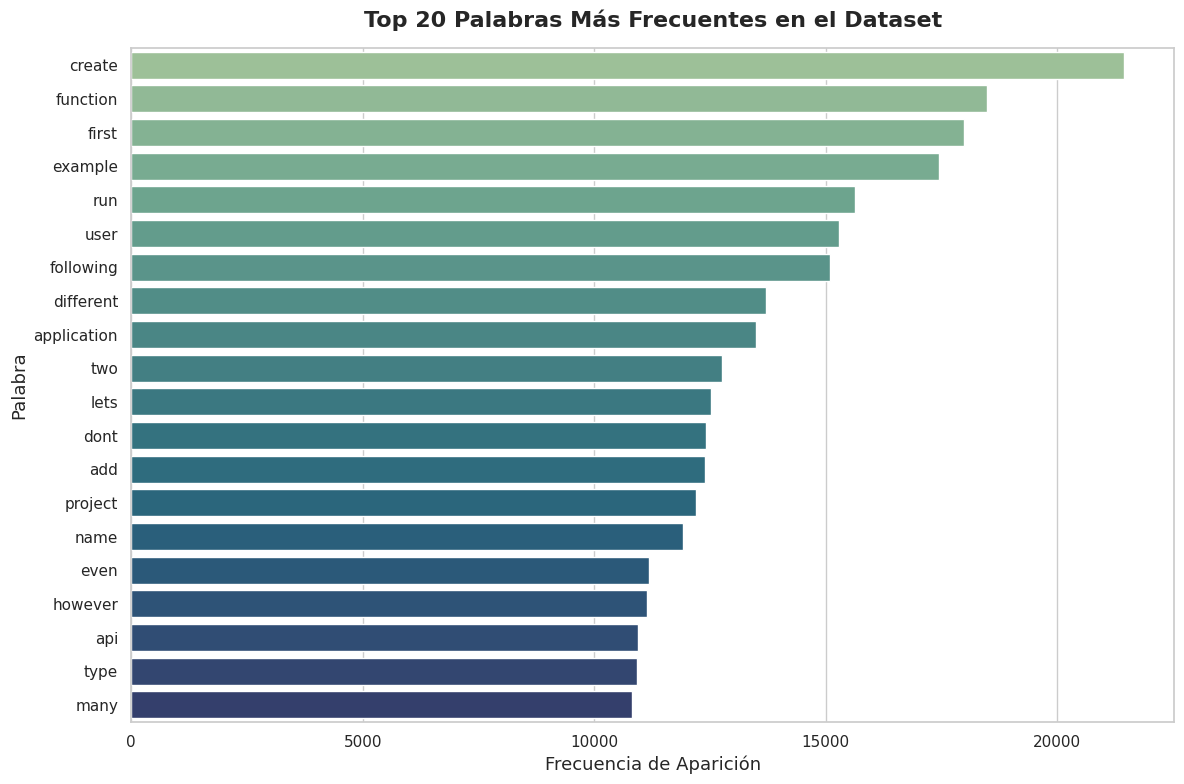

In [36]:
# Configuración del gráfico
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# Crear gráfico de barras horizontales
ax = sns.barplot(
    x="Frecuencia",
    y="Palabra",
    data=df_top_palabras,
    palette="crest",
    hue="Palabra",
    legend=False,
)

# Títulos y etiquetas
plt.title(
    "Top 20 Palabras Más Frecuentes en el Dataset",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Frecuencia de Aparición", fontsize=13)
plt.ylabel("Palabra", fontsize=13)

# Mostrar el gráfico
plt.tight_layout()
plt.savefig(
    'top_palabras_frecuentes.png', dpi=300, bbox_inches='tight'
)
plt.show()

### Palabras más características por categoría

El Top-20 general mezcla todas las categorías. Lo más útil para un clasificador es ver qué palabras distinguen a cada categoría de las demás: eso es justo lo que el modelo tiene que aprender a detectar. Se usa TF-IDF por categoría (promedio de los documentos de esa clase) para encontrar las palabras más distintivas.

In [37]:

warnings.filterwarnings('ignore', message='Your stop_words may be inconsistent')

vectorizador = TfidfVectorizer(
    max_features=5000,
    stop_words=list(stopwords_es_ing),
    min_df=5,
)
matriz_tfidf = vectorizador.fit_transform(df['texto_limpio'].fillna(''))
vocabulario = vectorizador.get_feature_names_out()

palabras_por_categoria = {}
for categoria in df['categoria_final'].unique():
    idx = df.index[df['categoria_final'] == categoria]
    promedio_tfidf = matriz_tfidf[idx].mean(axis=0).A1
    top_idx = promedio_tfidf.argsort()[::-1][:10]
    palabras_por_categoria[categoria] = [(vocabulario[i], round(promedio_tfidf[i], 4)) for i in top_idx]

print("--- PALABRAS MAS CARACTERISTICAS POR CATEGORIA (TF-IDF) ---")
for categoria, palabras in palabras_por_categoria.items():
    print(f"\n{categoria}:")
    print(', '.join([p for p, _ in palabras]))


--- PALABRAS MAS CARACTERISTICAS POR CATEGORIA (TF-IDF) ---

Frontend:
css, html, js, component, javascript, react, page, function, tried, type

Ciencia de Datos:
matlab, plot, function, model, values, column, dataframe, dataset, spark, example

Mobile:
android, view, ios, swift, kotlin, flutter, tried, screen, project, class

Backend:
api, class, method, php, application, java, tried, ruby, following, go

Bases de Datos:
table, query, sql, database, column, tables, rows, id, columns, tried

Programación General:
function, python, rust, following, output, example, perl, tried, program, array

DevOps / Cloud:
docker, run, project, build, aws, command, container, running, tried, server

Seguridad:
security, key, token, server, access, user, information, password, encryption, hash


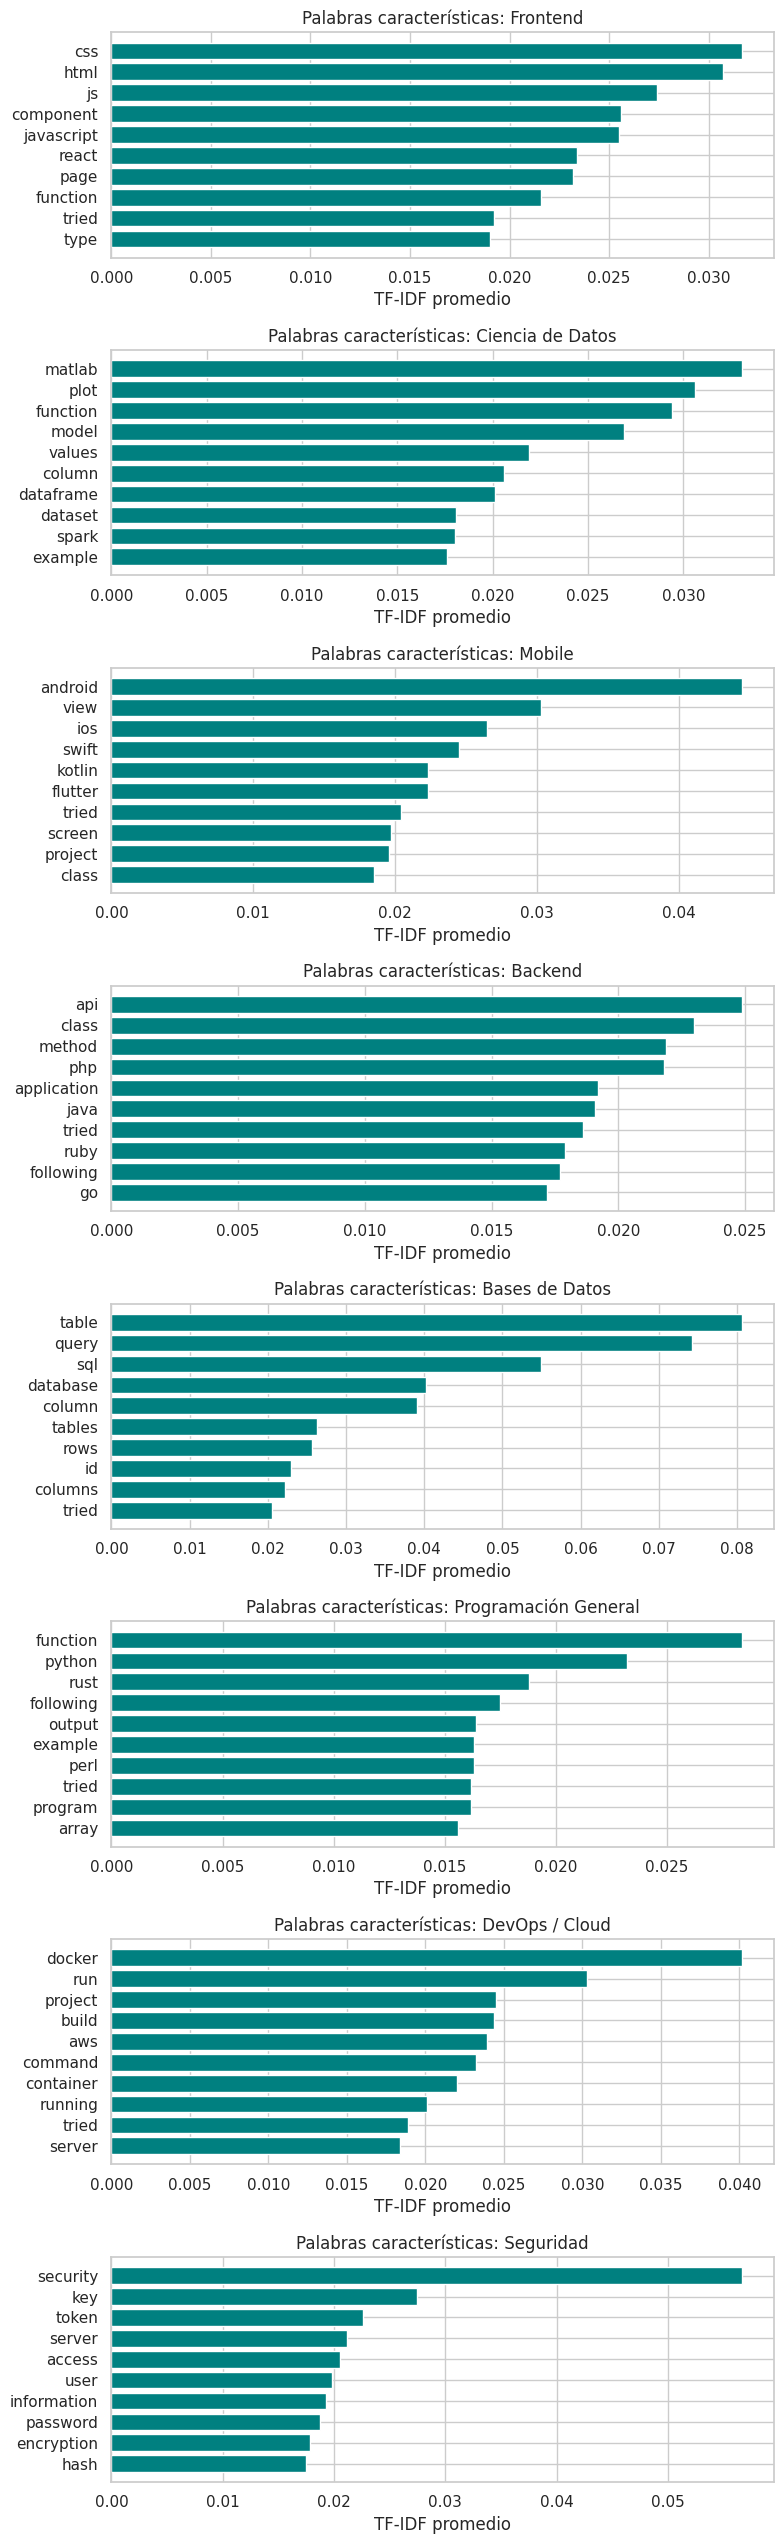

In [38]:
fig, axes = plt.subplots(len(palabras_por_categoria), 1, figsize=(8, 3.2 * len(palabras_por_categoria)))
for ax, (categoria, palabras) in zip(axes, palabras_por_categoria.items()):
    nombres = [p for p, _ in palabras][::-1]
    valores = [v for _, v in palabras][::-1]
    ax.barh(nombres, valores, color='teal')
    ax.set_title(f'Palabras características: {categoria}')
    ax.set_xlabel('TF-IDF promedio')

plt.tight_layout()
plt.savefig('palabras_caracteristicas_por_categoria.png', dpi=300, bbox_inches='tight')
plt.show()


#Validar el balance del dataset
##Determinar cuantitativamente si las clases están equilibradas o si existe un desbalance severo que requiera técnicas de corrección.

In [39]:
conteo_clases = df['categoria_final'].value_counts()
ratio_desbalance = conteo_clases.max() / conteo_clases.min()

print("--- VALIDACIÓN DE BALANCE DE CLASES ---")
print(f"Clase mayoritaria: {conteo_clases.idxmax()} ({conteo_clases.max()} registros)")
print(f"Clase minoritaria: {conteo_clases.idxmin()} ({conteo_clases.min()} registros)")
print(f"Ratio de desbalance (Max/Min): {ratio_desbalance:.2f}")

if ratio_desbalance > 3:
    print("El dataset presenta un desbalance significativo. Se recomienda aplicar oversampling o usar métricas ponderadas.")
else:
    print(" El dataset se encuentra razonablemente equilibrado.")

--- VALIDACIÓN DE BALANCE DE CLASES ---
Clase mayoritaria: Frontend (5402 registros)
Clase minoritaria: Seguridad (2792 registros)
Ratio de desbalance (Max/Min): 1.93
 El dataset se encuentra razonablemente equilibrado.


## Documentar hallazgos: Conclusiones del EDA

In [40]:
hallazgos = f"""
# Informe de Análisis Exploratorio (EDA) - Dataset TechMind

## Hallazgos y decisiones

- **Sesgo de idioma ({df['idioma'].value_counts(normalize=True).get('en', 0)*100:.1f}% inglés):**
  nos apoyamos en el vocabulario técnico, que es prácticamente igual en ambos idiomas
  (docker, python, API, etc.), por lo que no se considera bloqueante para el modelo.

- **Sesgo de fuente ({df['fuente'].value_counts(normalize=True).get('stackoverflow', 0)*100:.1f}% Stack Overflow):**
  el corpus está compuesto mayormente por preguntas y respuestas de foro, no por documentación
  formal. El modelo debe interpretarse como clasificador de *preguntas técnicas*, no de documentación.

- **Balance de clases (ratio {conteo_clases.max()/conteo_clases.min():.2f}):**
  el dataset está razonablemente equilibrado; no es indispensable aplicar oversampling/undersampling
  agresivo, aunque sí conviene vigilar la clase minoritaria.

- **Longitud de documentos:** la mayoría se concentra en un rango razonable, pero existen outliers
  extremos (hasta {int(maximo)} palabras). Se decidió truncar a {int(p99)} palabras (percentil 99)
  en vez de descartarlos, para no perder la señal de categoría que aportan.

- **Valores faltantes y duplicados:** {int(nulos_total.sum())} valores faltantes detectados
  y {int(duplicados_exactos)} duplicados exactos encontrados en este dataset.

- **Categorías más frecuentes vs. minoritarias:** la categoría mayoritaria es
  '{conteo_clases.idxmax()}' ({conteo_clases.max()} registros) y la minoritaria es
  '{conteo_clases.idxmin()}' ({conteo_clases.min()} registros).

- **Palabras características por categoría:** el análisis de TF-IDF por categoría muestra
  vocabulario distintivo y coherente por clase, lo que sugiere que las categorías sí son
  separables para un clasificador de texto.
"""

with open('informe_analisis_eda.md', 'w', encoding='utf-8') as f:
    f.write(hallazgos)

print(hallazgos)
print("Informe guardado en informe_analisis_eda.md")



# Informe de Análisis Exploratorio (EDA) - Dataset TechMind

## Hallazgos y decisiones

- **Sesgo de idioma (95.9% inglés):**
  nos apoyamos en el vocabulario técnico, que es prácticamente igual en ambos idiomas
  (docker, python, API, etc.), por lo que no se considera bloqueante para el modelo.

- **Sesgo de fuente (66.8% Stack Overflow):**
  el corpus está compuesto mayormente por preguntas y respuestas de foro, no por documentación
  formal. El modelo debe interpretarse como clasificador de *preguntas técnicas*, no de documentación.

- **Balance de clases (ratio 1.93):**
  el dataset está razonablemente equilibrado; no es indispensable aplicar oversampling/undersampling
  agresivo, aunque sí conviene vigilar la clase minoritaria.

- **Longitud de documentos:** la mayoría se concentra en un rango razonable, pero existen outliers
  extremos (hasta 32702 palabras). Se decidió truncar a 2594 palabras (percentil 99)
  en vez de descartarlos, para no perder la señal de categoría que apor

## Proponer mejoras al dataset: Recomendaciones

In [41]:
recomendaciones = """
# Recomendaciones para mejorar el dataset TechMind

1. Revisar el paso de mapeo de categorías: confirmar que las 8
   categorías originales quedan representadas en el dataset limpio; un mismatch de acentos
   o mayúsculas puede descartar una categoría completa sin aviso.

2. Ampliar la recolección en las categorías minoritarias (ej. Seguridad) para reducir la
   dependencia de oversampling y mejorar la calidad real de esa clase.

3. Balancear la proporción de fuentes: incorporar más contenido de documentación oficial y
   artículos especializados para no depender tanto de preguntas de Stack Overflow.

4. Aplicar un truncado consistente a los documentos por encima del percentil 99 de longitud
   antes de tokenizar, para evitar que outliers extremos distorsionen el entrenamiento.

5. Incorporar más contenido en español si el modelo debe usarse en ese idioma en producción,
   ya que hoy el dataset es mayoritariamente en inglés.

6. Usar las palabras características por categoría (TF-IDF) como insumo para revisar manualmente
   si alguna categoría tiene vocabulario ambiguo o solapado con otra, antes de entrenar el modelo.
"""

with open('recomendaciones_dataset.md', 'w', encoding='utf-8') as f:
    f.write(recomendaciones)

print(recomendaciones)
print("Recomendaciones guardadas en recomendaciones_dataset.md")



# Recomendaciones para mejorar el dataset TechMind

1. Revisar el paso de mapeo de categorías: confirmar que las 8
   categorías originales quedan representadas en el dataset limpio; un mismatch de acentos
   o mayúsculas puede descartar una categoría completa sin aviso.

2. Ampliar la recolección en las categorías minoritarias (ej. Seguridad) para reducir la
   dependencia de oversampling y mejorar la calidad real de esa clase.

3. Balancear la proporción de fuentes: incorporar más contenido de documentación oficial y
   artículos especializados para no depender tanto de preguntas de Stack Overflow.

4. Aplicar un truncado consistente a los documentos por encima del percentil 99 de longitud
   antes de tokenizar, para evitar que outliers extremos distorsionen el entrenamiento.

5. Incorporar más contenido en español si el modelo debe usarse en ese idioma en producción,
   ya que hoy el dataset es mayoritariamente en inglés.

6. Usar las palabras características por categoría (TF-IDF)